In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr

## Задача 1

In [ ]:
import pandas as pd
from scipy.stats import spearmanr

df = pd.read_csv('t_54.csv', sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
df = df.dropna()
regions = df['регион'].unique()
ans = [['регион', 'р-уровень']]
for region in regions:
  df_new = df[df['регион'] == region]
  ans.append([region, round(float(st.mannwhitneyu(df_new['время_до'], df_new['время_после'])[1]), 4)])
ans = [ans[0]] + sorted(ans[1:], key=lambda x: x[1])
print(ans)


Северо-запад
Урал
Центр
[['регион', 'p-уровень'], ['Центр', 0.004]]


In [ ]:
from operator import itemgetter
from scipy.stats import ...

In [ ]:
dd = df.copy()


...

dd.sort(key=itemgetter(...))
...

print(m_test)

## Задача 2

Даны пять показателей здоровья по двум группам пациентов. Все пациенты в таблице записаны по строкам. Разделение по группам происходит с помощью столбца group. Необходимо написать программу, которая бы выводила р-уровень при сравнении всех количественных факторов здоровья по двум группам между собой

В программе необходимо учесть:

Если данные в обеих группах распределены нормально, то для сравнения использовать метод Стьюдент с различной дисперсией. Если хотя бы в одной группе - не нормальное распределение, то для сравнения использовать метод Манн-Уитни. Для проверки на нормальность использовать метод Шапиро c уровнем принятия решения 0.05.
Результат вывести в виде списка списков. Первый список - названия выводимых результатов: ['показатель', 'р-уровень', 'метод расчёта']. Остальные списки - расчёты по каждому фактору.
Значение р-уровня округлить до 4 знака.
Для расчёта использовать библиотеку scipy.stats
Выходной список списков отсортировать по значению р-уровню в порядке убывания

In [ ]:
df = pd.read_csv('t5.csv', sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
df = df.dropna()
df_new = df.drop('group', axis=1)
columns = df_new.columns.to_list()
ans = [['показатель', 'р-уровень', 'метод расчёта']]
for column in columns:
    g1 = df[df['group'] == 'group_1'][column]
    g2 = df[df['group'] == 'group_2'][column]
    if((st.shapiro(g1)[1] >= 0.05) and (st.shapiro(g2)[1] >= 0.05)):
        ans.append([column, round(float(st.ttest_ind(g1, g2)[1]), 4), 'Стьюдент'])
    else:
        ans.append([column, round(float(st.mannwhitneyu(g1, g2)[1]), 4), 'Манн-Уитни'])
ans = [ans[0]] + sorted(ans[1:], key=lambda x: x[1])
print(ans)

[['показатель', 'р-уровень', 'метод расчёта'], ['V, мм/с', 0.2019], ['Av, мДж/с', 0.202], ['Y, мм ', 0.6069], ['S, мм.кв', 0.9123], ['X, мм', 0.9927]]


In [ ]:
from operator import itemgetter
from scipy.stats import mannwhitneyu, ttest_ind, shapiro

In [ ]:
dd = df.copy()

если ((shapiro(g1)[1] >= 0.05) and (shapiro(g2)[1] >= 0.05)):
то применяем Стьюдент
иначе применяем Манна-Уитни

....

print(m_test)

### Дополнительно

In [ ]:
0.003

## Задача 3

In [ ]:
df = pd.read_csv('t51.csv', sep=';', encoding='cp1251', skipinitialspace=True)
df = df.dropna()
nominal_columns = ['тип_осложнения_1', 'тип_осложнения_2', 'тип_осложнения_3', 'тип_осложнения_4']
group = 'вид_зондирования'
ans = [['показатель', 'р-уровень']]
for col in nominal_columns:
    cont = pd.crosstab(df[group], df[col])
    ans.append([col, round(float(st.chi2_contingency(cont)[1]), 4)])
ans = [ans[0]] + sorted(ans[1:], key=lambda x: x[1])
print(ans)

[['показатель', 'р-уровень'], ['тип_осложнения_1', 0.0045], ['тип_осложнения_4', 0.3886], ['тип_осложнения_2', 0.4974], ['тип_осложнения_3', 1.0]]


## Задача 4

In [ ]:
df = pd.read_csv('t_51.csv',sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
df = df.dropna()
df = df[df['Группа'] == 'Группа_1']
df = df.drop('Группа', axis=1)
columns = df.columns.to_list()
s = set()
ans = [['показатель_1', 'показатель_2', 'значение корреляции', 'р-уровень', 'метод корреляции']]
for column1 in columns:
    for column2 in columns:
        if (column1 != column2 and (column1, column2) not in s):
            if ((st.shapiro(df[column1])[1] >= 0.05) and (st.shapiro(df[column2])[1] >= 0.05)):
                ans.append([column1, column2, round(float(st.pearsonr(df[column1], df[column2])[0]), 2), round(float(st.pearsonr(df[column1], df[column2])[1]), 4), 'Пирсон'])
                s.add((column1, column2))
                s.add((column2, column1))
            else:
                ans.append([column1, column2, round(float(st.spearmanr(df[column1], df[column2])[0]), 2), round(float(st.spearmanr(df[column1], df[column2])[1]), 4), 'Спирмен'])
                s.add((column1, column2))
                s.add((column2, column1))
ans = [ans[0]] + sorted(ans[1:], key=lambda x: x[2], reverse=True)
ans_new = [['показатель_1', 'показатель_2', 'значение корреляции', 'р-уровень', 'метод корреляции']]
for x in ans[1:]:
    if (x[3] < 0.05):
        ans_new.append(x)
print(ans_new)

р-уровень
0.0
0.0001
0.0002
0.0008
0.0036
0.0276
0.0415
0.0721
0.0906
0.1196
0.132
0.1497
0.1839
0.206
0.3063
0.304
0.3529
0.3485
0.3861
0.4598
0.8141
0.8671
0.9272
0.977
0.8087
0.688
0.5778
0.5118
0.5086
0.3
0.2829
0.2495
0.2395
0.2336
0.1874
0.1923
0.1677
0.0868
0.0823
0.0292
0.0123
0.0099
0.0052
0.0025
0.0001
[]


In [ ]:
from scipy.stats import pearsonr, spearmanr, shapiro
from operator import itemgetter

## Задача 5

Перед вами данные, как и в первой задаче.
Там речь шла об интернет-компании “Шарики к празднику”.
Она внедряла улучшения в дизайне сайта. Новая версия сайта работала на трёх регионах: ['Северо-запад', 'Урал', 'Центр'].

В исходной таблице три столбца: время_до, время_после, регион

Построить график "ящик с усами" по факторам время_до, время_после.
Необходимо учесть:

Два ящика выводить на одном графике;
Сделать код, который бы строил график по одному региону. Регион вводится;
Параметры графика оставить по умолчанию.

Урал


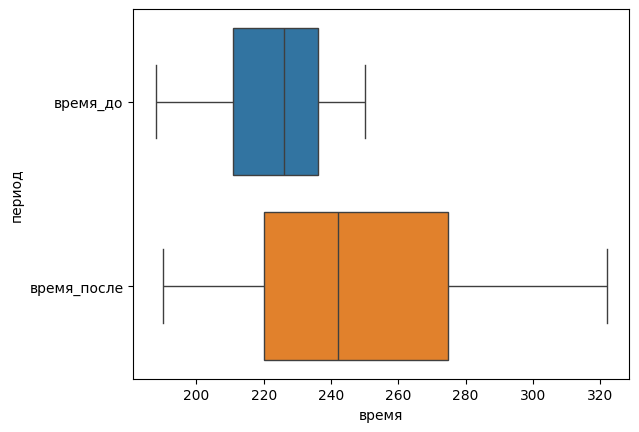

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('t_54.csv', sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
df = df.dropna()
region = input()
df = df[df['регион'] == region]
sns.boxplot(data=[df['время_до'], df['время_после']], orient='h')
plt.xlabel('время')
plt.ylabel('период')
plt.savefig('target_5_5.png')
plt.show()

Северо-запад


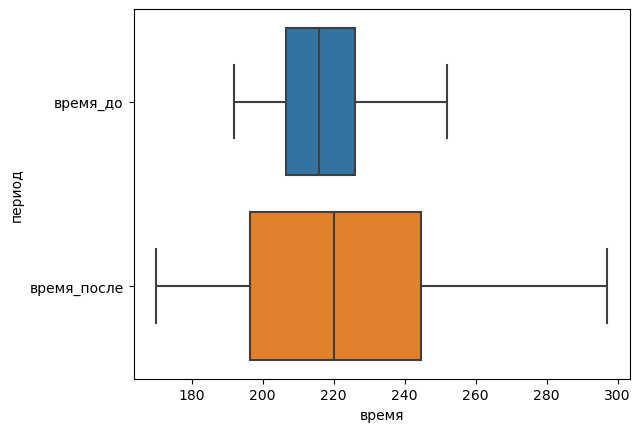

In [ ]:
....
df.columns = ...
df = ...
df = ...
...
sns.boxplot(x='время', y='период', data=df)
plt.show()


![image.png](attachment:image.png)

Пример ответа:

![image.png](attachment:image.png)